### Goal: 
Predict the price of a diamond using its physical and quality features from built-in seaborn "diamonds" dataset 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# nicer plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# load the data
df = sns.load_dataset('diamonds')
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())  # should be all zeros

(53940, 10)
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-

#### EDA

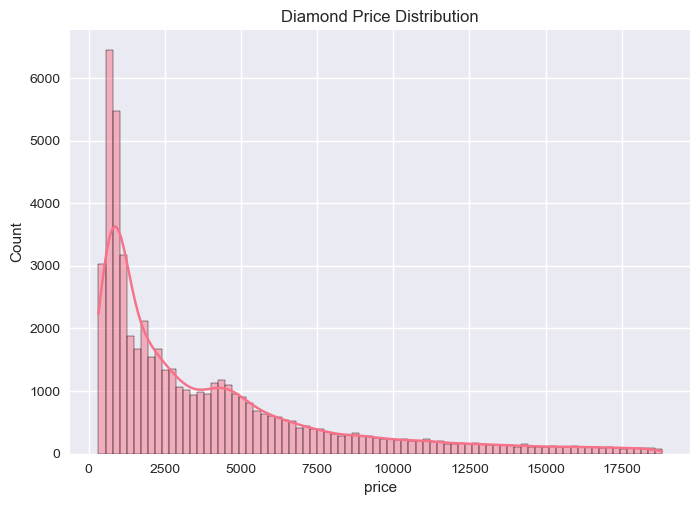

In [3]:
# 1. Target distribution
sns.histplot(df['price'], kde=True)
plt.title('Diamond Price Distribution')
plt.show()

Clear right-skewed distribution

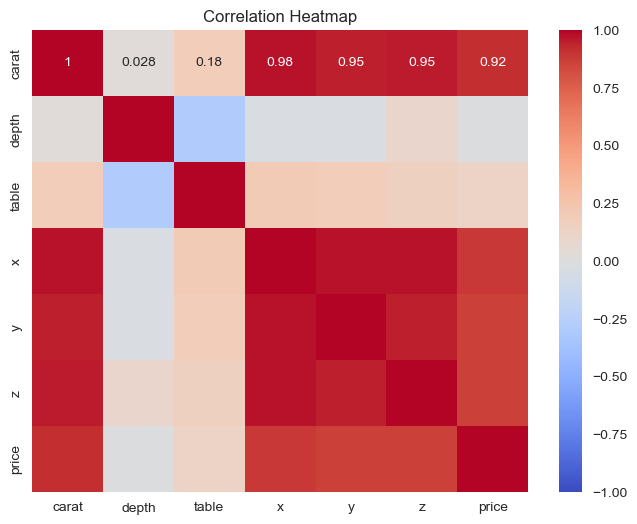

In [4]:
# 2. Numerical correlations
numerical = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
corr = df[numerical].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [5]:
corr

,carat,depth,table,x,y,z,price
carat,1.000000,0.028224,0.181618,0.975094,0.951722,0.953387,0.921591
depth,0.028224,1.000000,-0.295779,-0.025289,-0.029341,0.094924,-0.010647
table,0.181618,-0.295779,1.000000,0.195344,0.183760,0.150929,0.127134
x,0.975094,-0.025289,0.195344,1.000000,0.974701,0.970772,0.884435
y,0.951722,-0.029341,0.183760,0.974701,1.000000,0.952006,0.865421
z,0.953387,0.094924,0.150929,0.970772,0.952006,1.000000,0.861249
price,0.921591,-0.010647,0.127134,0.884435,0.865421,0.861249,1.000000


#### Key insights:  
- carat has the strongest correlation with  price (~0.92)
- x, y, z dimensions are almost perfectly correlated with carat(mulivollinearity warning!)

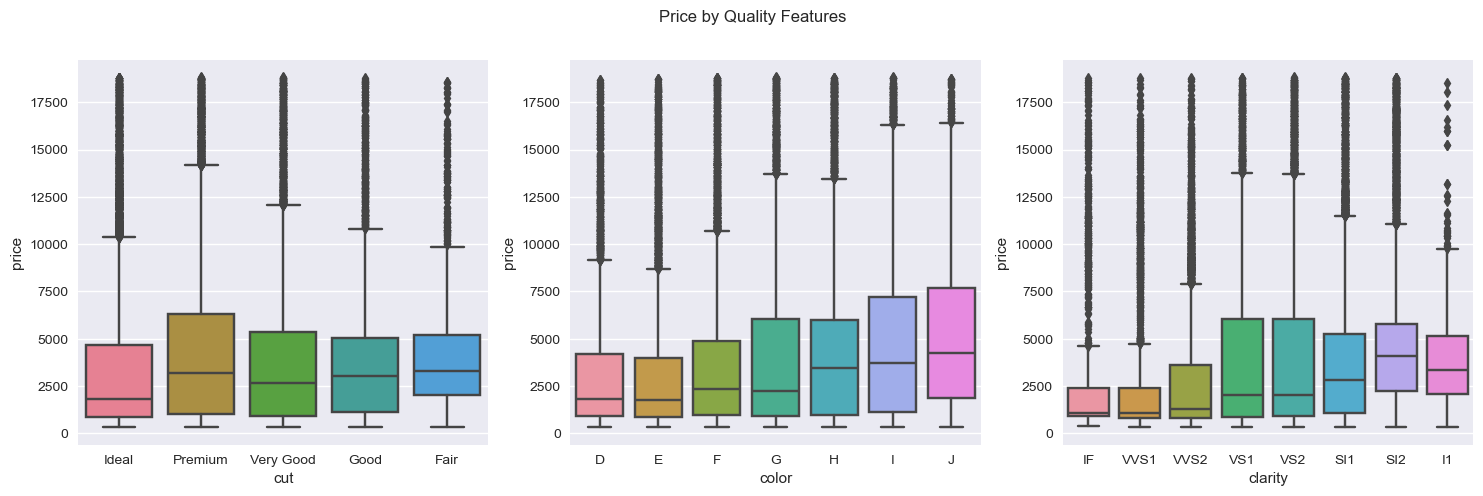

In [6]:
# 3. Categorical vs Price
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.boxplot(x='cut', y='price', data=df, ax=axes[0])
sns.boxplot(x='color', y='price', data=df, ax=axes[1])
sns.boxplot(x='clarity', y='price', data=df, ax=axes[2])
plt.suptitle('Price by Quality Features')
plt.show()

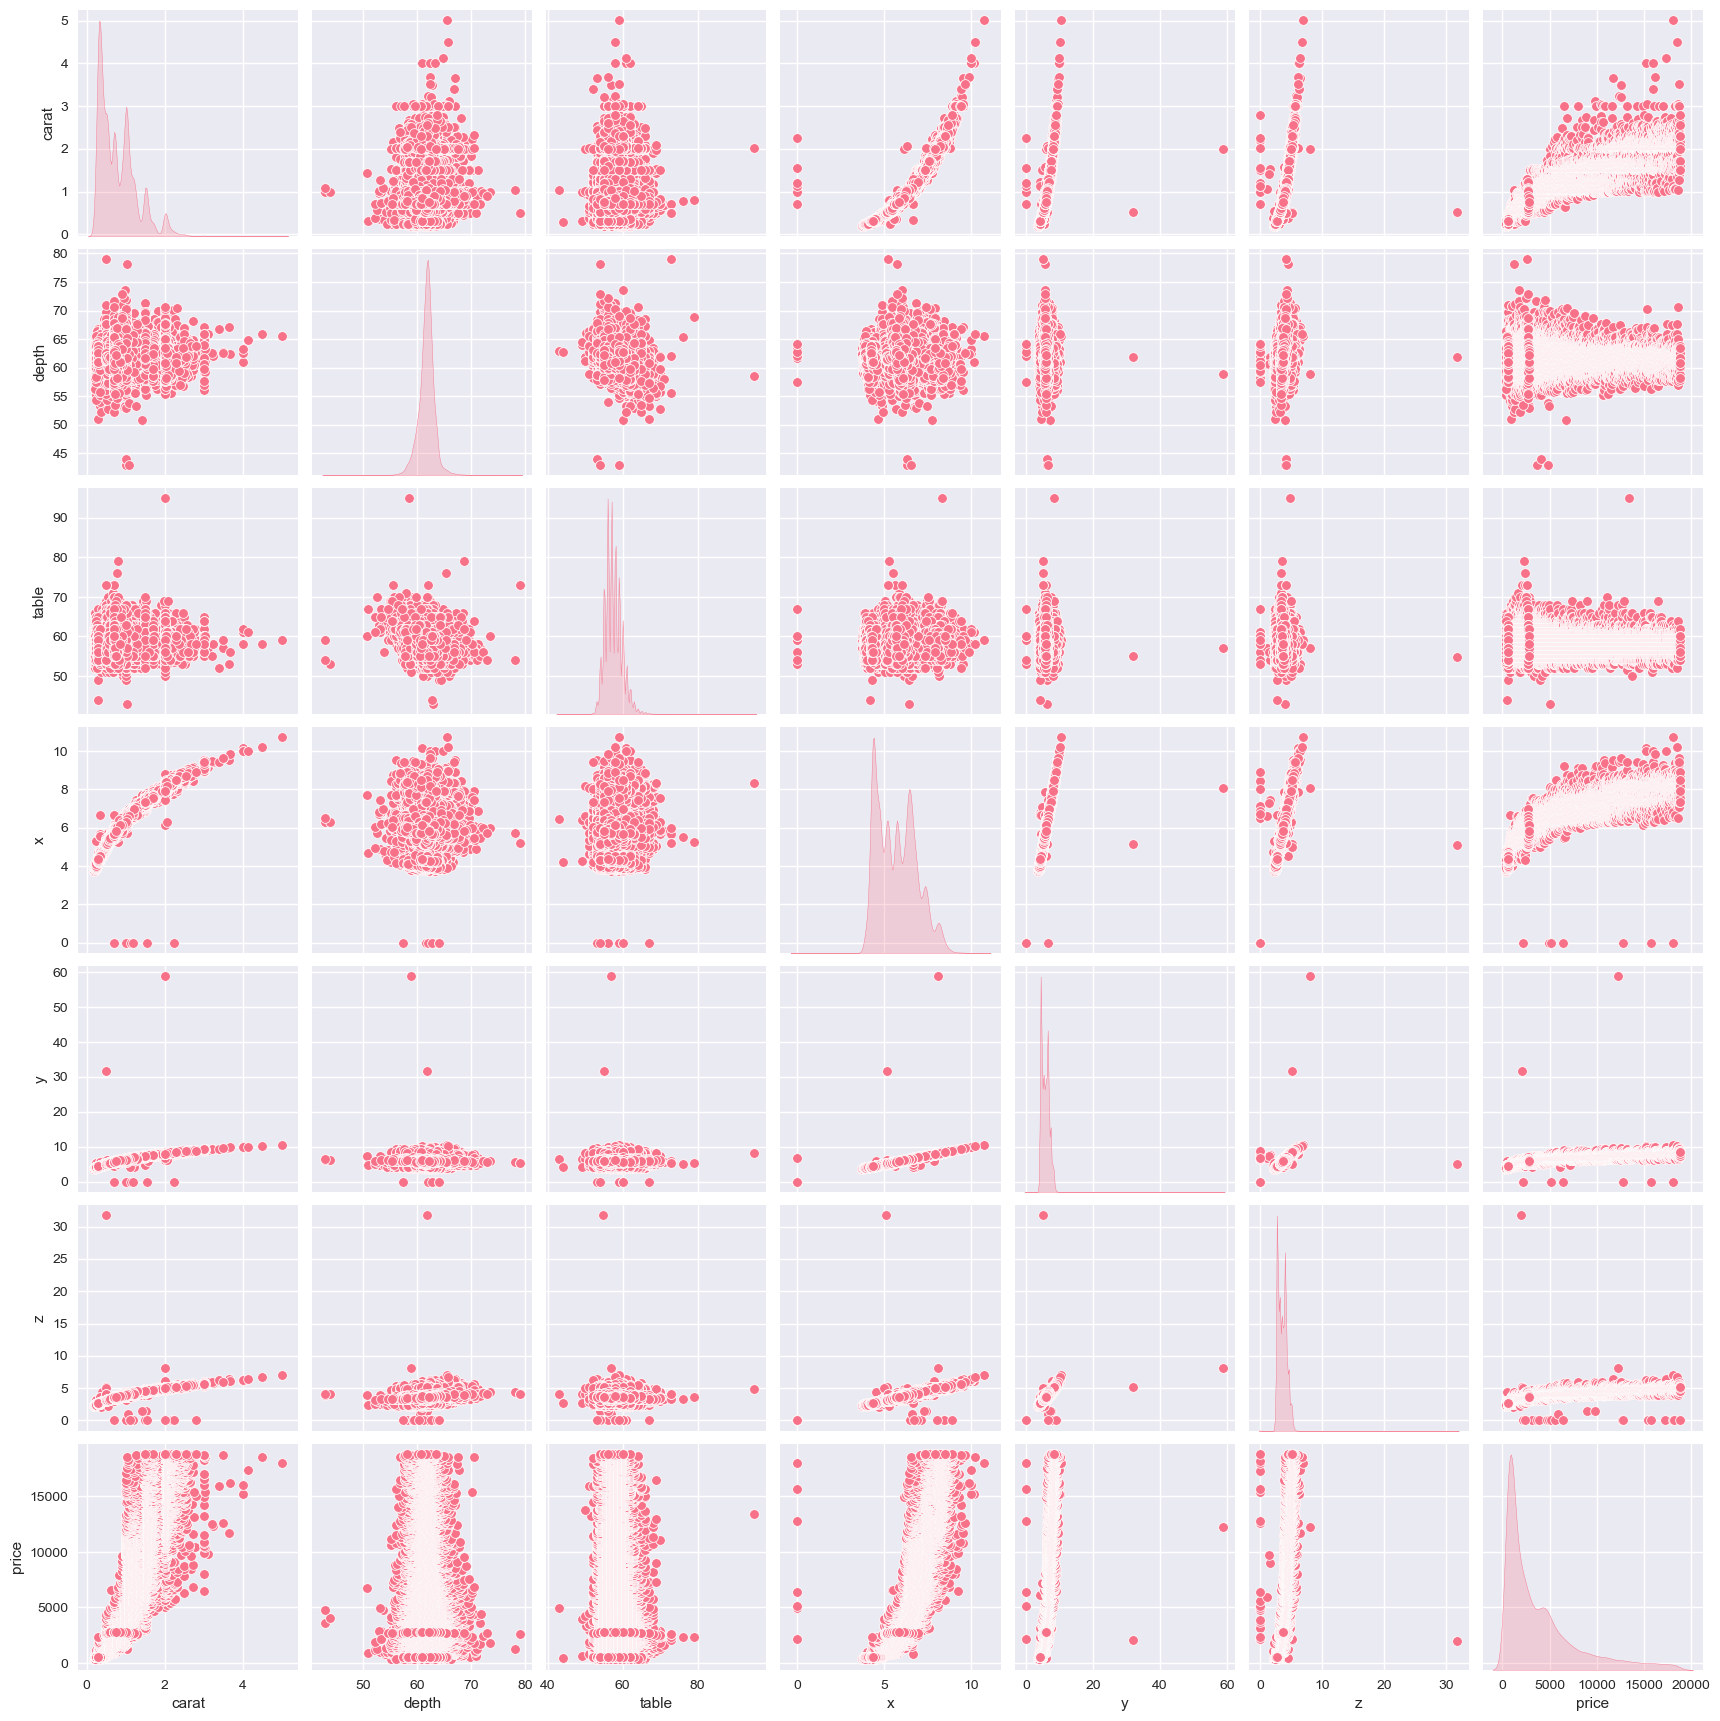

In [7]:
# 4. Pairplot (numerical + target) — optional but insightful
sns.pairplot(df[numerical], diag_kind='kde')  # takes ~30 sec

#### Data Preprocessing

In [8]:
# One-hot encode categorical features (drop_first avoids dummy variable trap)
df_encoded = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)
# Features & target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print("Features shape:", X.shape)

Features shape: (53940, 23)


#### Data Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (43152, 23), Test: (10788, 23)


#### Model Training

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Training completed!")

Training completed!


#### Evaluation

In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $737.15
RMSE: $1135.21
R²:   0.9189


- MAE: on average, predictions are of by about 737USD (average diamond price is ~3,930USD)  
- RMSE: $1135.21(since it penalizes larger errors more)
- High R² shows the model explains  92% of price variation, while RMSE flags larger errors in high-price ranges

#### Interpretation

In [12]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients.head(10))
print("\n... and the bottom ones:")
print(coefficients.tail(5))

          Feature   Coefficient
0           carat  11280.784327
4               y     -3.528450
2           table    -26.600021
5               z    -36.463370
1           depth    -65.091015
6     cut_Premium    -76.887768
7   cut_Very Good   -108.863766
10        color_E   -218.198603
8        cut_Good   -267.018777
11        color_F   -279.716403

... and the bottom ones:
        Feature  Coefficient
14      color_I -1479.584470
20  clarity_SI1 -1690.530044
15      color_J -2372.019835
21  clarity_SI2 -2664.504626
22   clarity_I1 -5365.944596


#### Residual plot

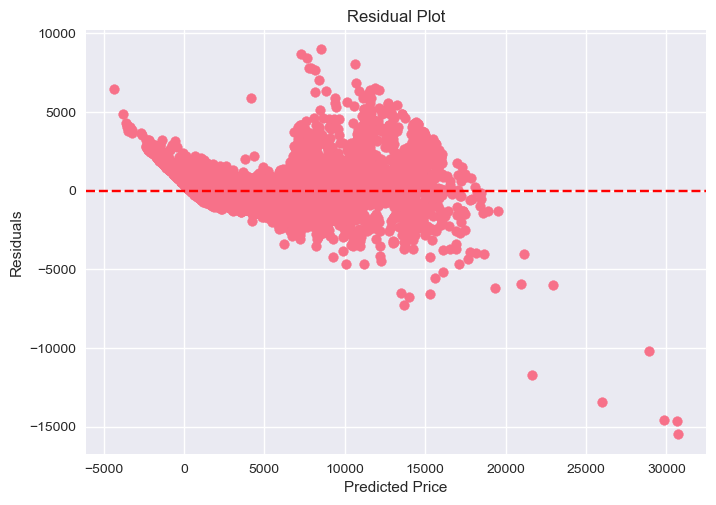

In [13]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

- Residual plot reveals heteroscadasticity with a curved pattern and increasing variance at higher predicted prices
- Large neagtive residuals at high predicted prices indicate overprediction for expensive diamonds
- The x-axis goes negative(big red flag) - for some very small diamonds the model is outputting negative prices

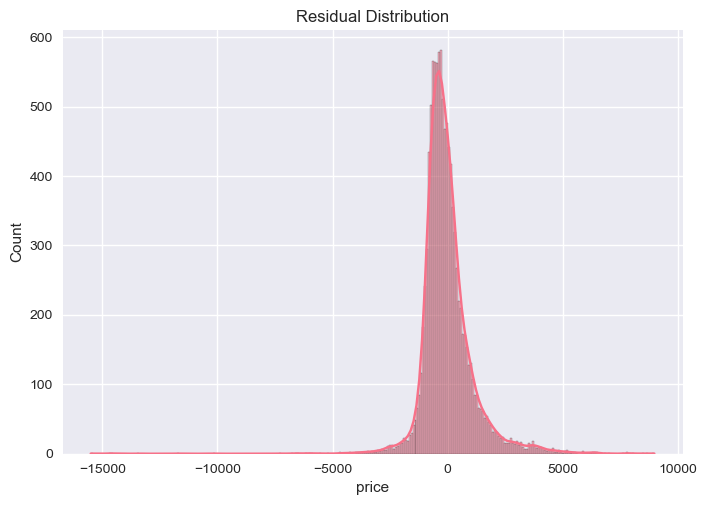

In [14]:
# Residual distribution
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

- Residual histogram shows a sharp peak near 0 with heavy tails, not perfectly symmetric. Approximately normal, but with a slight skewness and heavier tails than a normal distribution.

#### Overall conclusion:
- The model have strong predictive power(R²: 0.9189)
- Assumptions about linearity and homoscedasticity are violated which means while the model works decently, it`s not reliable for very cheap or very expensive diamonds. Confidence intervals/predictions could be misleading.

#### Quick Fixes:

In [15]:
# 1. Check how many negative predictions you actually have
neg_predictions = (y_pred < 0).sum()
print(f"Negative price predictions: {neg_predictions} out of {len(y_test)}")

Negative price predictions: 788 out of 10788


In [16]:
#2 Log-transform the target (prices are right-skewed)
y_log = np.log1p(y)  # log(1 + price) avoids log(0)

##### Re-split:

In [17]:
# Re-split and re-train (you can reuse the same X)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

##### Re-train model

In [18]:
model_log = LinearRegression()
model_log.fit(X_train, y_train_log)
y_pred_log = model_log.predict(X_test)

In [19]:
# Convert predictions back to original $ scale
y_pred_original = np.expm1(y_pred_log)

#### Updated evaluation:

In [20]:
mae_log = mean_absolute_error(y_test, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_log = r2_score(y_test, y_pred_original)

print(f"LOG MODEL → MAE: ${mae_log:.2f} | RMSE: ${rmse_log:.2f} | R²: {r2_log:.4f}")

LOG MODEL → MAE: $476.09 | RMSE: $1076.32 | R²: 0.9271


Previous ones:
- MAE:  737.15
- RMSE: 1135.21
- R²:   0.9189

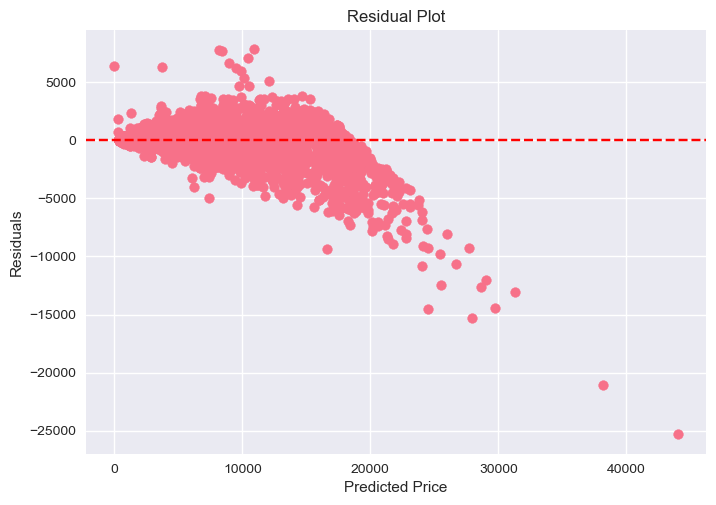

In [21]:
residuals = y_test - y_pred_original
plt.scatter(y_pred_original, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

New residual plot is cleaner, but still a mild downward fan pattern(positive residuals on cheap diamonds, negative on expensive ones)

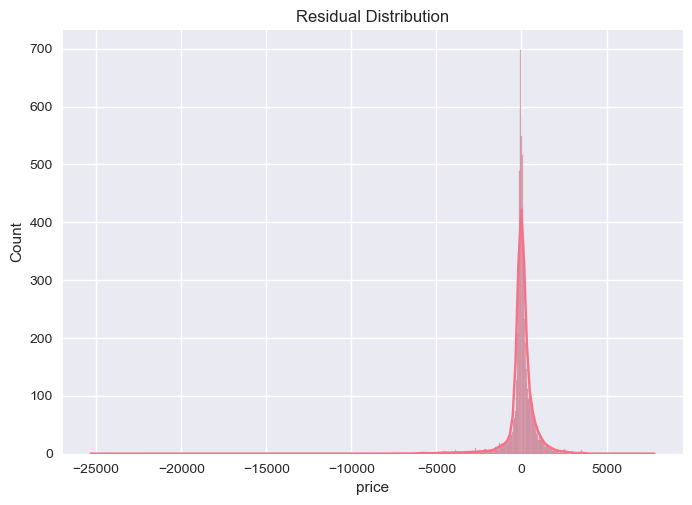

In [22]:
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

Step 10: What’s Next? (Level-up ideas)
Once you run everything:

1. Fix multicollinearity → drop x, y, z and re-train (compare R²).
2. Feature engineering → create volume = x * y * z.
3. Try log target: y_log = np.log1p(y) → often boosts R² on skewed prices.
4. Regularization: Replace LinearRegression with Ridge or Lasso from sklearn.linear_model.
5. Cross-validation: from sklearn.model_selection import cross_val_score.
6. Pipeline: Wrap everything in sklearn.pipeline for production feel.

#### Final Pipeline

- Automatic scaling and encoding
- Ridge regularization(handles the carat + x/y/z multicollinearity)
- Log target transformation

In [23]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
categorical_features = ['cut', 'color', 'clarity']
numerical_features    = ['carat', 'depth', 'table', 'x', 'y', 'z']

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'  # safety in case we add more columns later
)

In [26]:
# FULL PIPELINE with LOG TARGET
pipeline = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('ridge', Ridge(alpha=1.0))          # alpha=1 is a good starting point
    ]),
    func=np.log1p,          # log(1 + price)
    inverse_func=np.expm1   # convert back to dollars
)

In [27]:
# TRAIN-TEST SPLIT
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
# FIT - PREDICT
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [29]:
# EVALUATION
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"FULL PIPELINE MODEL")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")

FULL PIPELINE MODEL
MAE:  $476.35
RMSE: $1078.51
R²:   0.9268


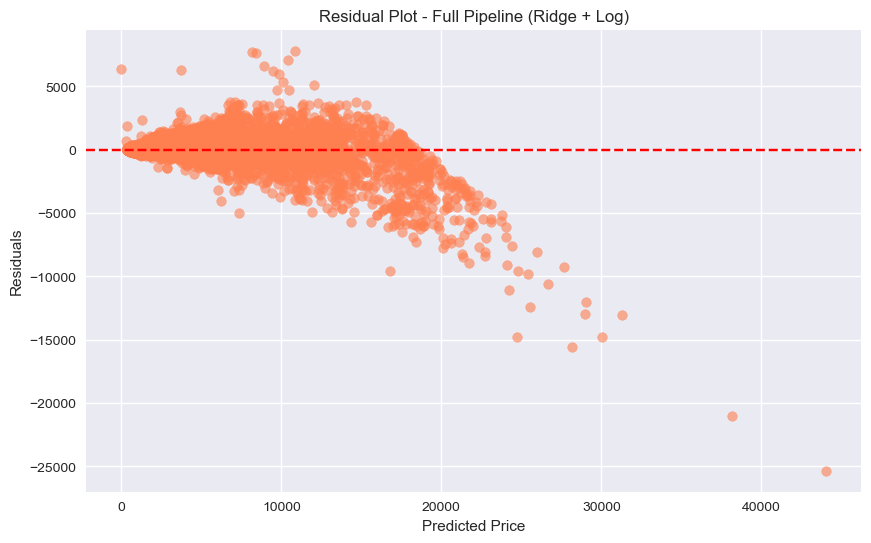

In [30]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='coral')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot - Full Pipeline (Ridge + Log)')
plt.grid(True)
plt.show()

- No negative prices, tigher spread on cheap diamonds.
- Still present mild downward fan on the right side for predicted prices over 20k(model slightly overpredicts the most expensive diamonds)
- Slighter heteroscedasticity remains